
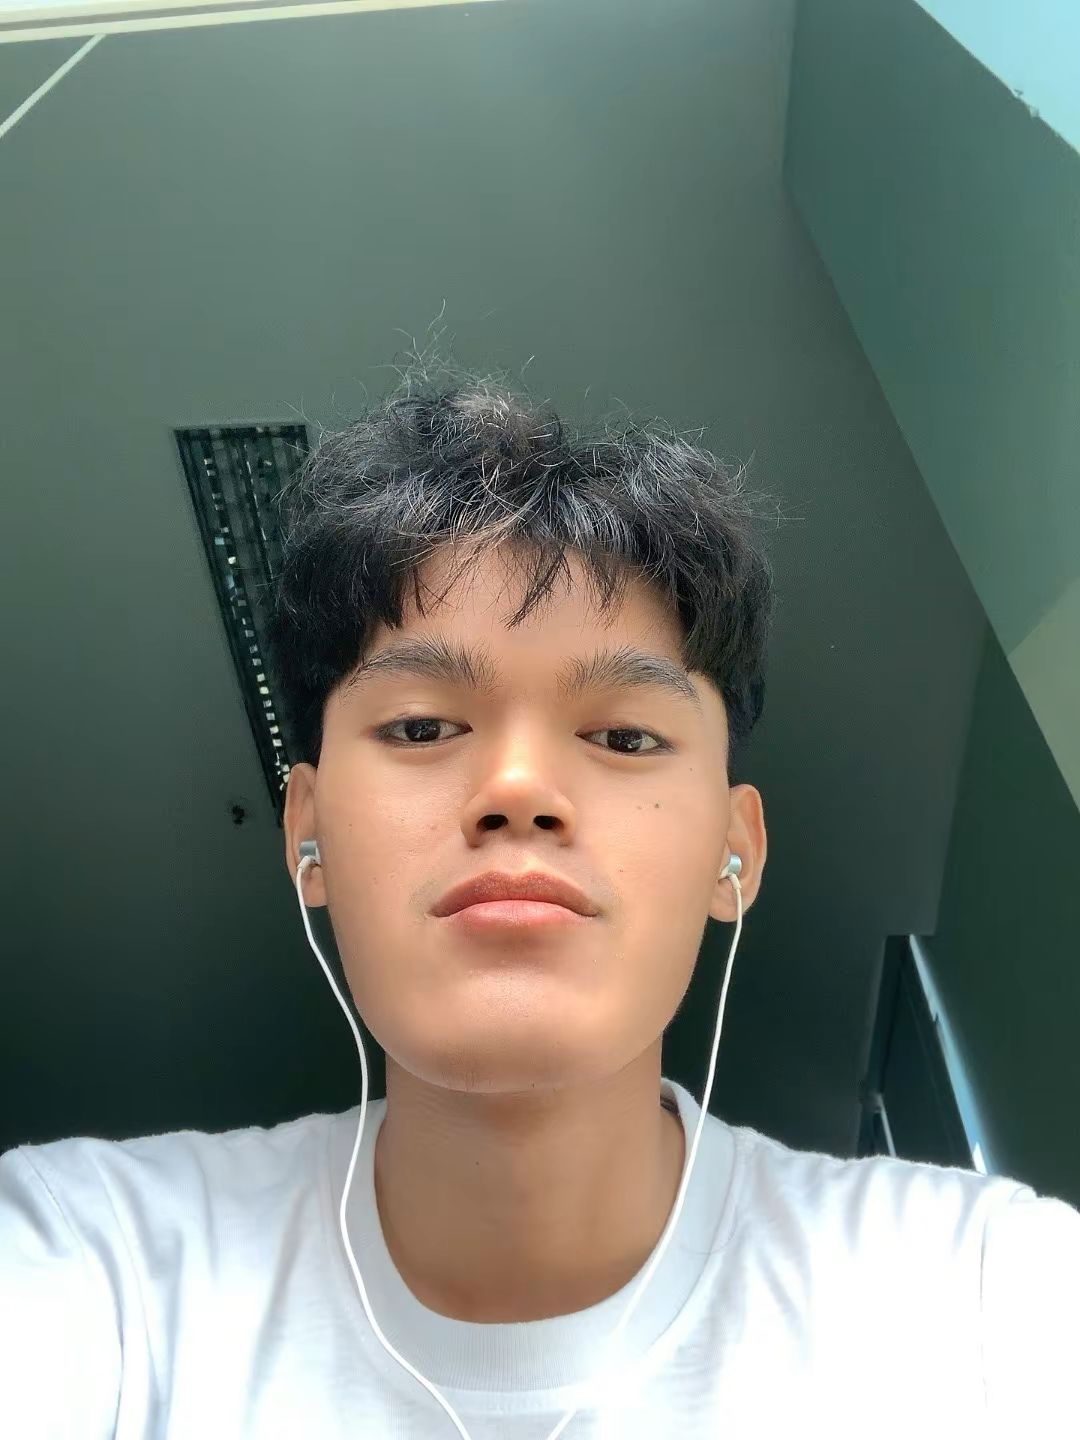

In [27]:
#@title Cover Page

import requests
from IPython.display import HTML, display
import base64

# Download foto dari Google Drive
file_id = "1Sp3etlSKkpolGWYaAsZUoLS7BGn8y3Hy"
image_url = f"https://drive.google.com/uc?export=download&id={file_id}"

response = requests.get(image_url)

with open("bagas.png", "wb") as file:
    file.write(response.content)

# Encode foto
with open("bagas.png", "rb") as image_file:
    encoded_string = base64.b64encode(image_file.read()).decode()

html_code = f"""
<!DOCTYPE html>
<html>
<head>
<meta charset="UTF-8">

<link rel="stylesheet"
href="https://cdnjs.cloudflare.com/ajax/libs/font-awesome/6.5.1/css/all.min.css">

<style>

body {{
    font-family: Arial, Helvetica, sans-serif;
    background: #121212;
    margin: 0;
    padding: 40px;
}}

.container {{
    max-width: 1200px;
    margin: auto;
    border-bottom: 3px solid #ff4d4d;
    padding-bottom: 25px;
}}

.header {{
    display: flex;
    align-items: center;
    gap: 35px;
}}

.photo {{
    width: 180px;
    height: 180px;
    border-radius: 50%;
    overflow: hidden;
    border: 4px solid #ff4d4d;
    flex-shrink: 0;
}}

.photo img {{
    width: 100%;
    height: 100%;
    object-fit: cover;
}}

.content {{
    flex: 1;
}}

.title {{
    color: #ff4d4d;
    font-size: 30px;
    font-weight: bold;
    line-height: 1.4;
    margin-bottom: 12px;
}}

.subtitle {{
    color: #a0a0a0;
    font-size: 16px;
    margin-bottom: 20px;
}}

.author {{
    font-size: 20px;
    font-weight: bold;
    color: #ffffff;
}}

.role {{
    color: #b0b0b0;
    font-size: 15px;
    margin-top: 4px;
}}

.social-icons {{
    margin-top: 18px;
    display: flex;
    gap: 12px;
}}

.social-icons a {{
    width: 38px;
    height: 38px;
    border-radius: 50%;
    border: 1px solid #444;
    background: #1e1e1e;

    display: flex;
    align-items: center;
    justify-content: center;

    text-decoration: none;
    color: #e0e0e0;

    transition: 0.2s ease;
}}

.social-icons a:hover {{
    background: #ff4d4d;
    color: #ffffff;
    border-color: #ff4d4d;
}}

</style>
</head>

<body>

<div class="container">

    <div class="header">

        <div class="photo">
            <img src="data:image/png;base64,{encoded_string}" alt="Bagas Aditya">
        </div>

        <div class="content">

            <div class="title">
                Prediksi Penjualan Mobil Bekas Menggunakan Algoritma XGBoost Regressor
            </div>

            <div class="subtitle">
                Data Analysis | Data Mining | Data Science | Machine Learning
            </div>

            <div class="author">
                Bagas Aditya
            </div>

            <div class="role">
                Data Analyst
            </div>

            <div class="social-icons">

                <a href="https://wa.me/6289622010731" target="_blank">
                    <i class="fab fa-whatsapp"></i>
                </a>

                <a href="https://www.linkedin.com/in/aditya-bagas/" target="_blank">
                    <i class="fab fa-linkedin-in"></i>
                </a>

                <a href="mailto:bagas331000@gmail.com">
                    <i class="fas fa-envelope"></i>
                </a>

                <a href="https://github.com/" target="_blank">
                    <i class="fab fa-github"></i>
                </a>

            </div>

        </div>

    </div>

</div>

</body>
</html>
"""

display(HTML(html_code))

# Aplikasi Prediksi Harga Jual Kembali Mobil Bekas

## Tahap 1: Definisi Masalah
Atasan memerlukan aplikasi untuk membangun model yang dapat memprediksi harga jual mobil bekas berdasarkan fitur-fitur seperti merek, model, tahun, jenis bahan bakar, transmisi, kilometer tempuh, dan spesifikasi mesin.

## Tahap 2: Pengumpulan Data

In [2]:
#@title Import Libraries & Konfigurasi Visualisasi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import joblib
import json
import os
import warnings
warnings.filterwarnings('ignore')

# Konfigurasi plot
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print("Semua pustaka berhasil dimuat.")

Semua pustaka berhasil dimuat.


In [3]:
#@title Memuat Dataset
df = pd.read_csv('cleaned_used_car_dataset.csv')
print(f"Dataset berhasil dimuat: {df.shape[0]} baris, {df.shape[1]} kolom")
print(f"\nKolom dataset:")
for col in df.columns:
    print(f"  - {col} ({df[col].dtype})")

Dataset berhasil dimuat: 5015 baris, 16 kolom

Kolom dataset:
  - Car_ID (object)
  - Brand (object)
  - Model (object)
  - Year (int64)
  - Fuel_Type (object)
  - Transmission (object)
  - KM_Driven (int64)
  - Owner (int64)
  - Engine_CC (float64)
  - Mileage_KMPL (float64)
  - Max_Power_BHP (float64)
  - Seats (int64)
  - Seller_Type (object)
  - Selling_Price_IDR (int64)
  - Vehicle_Age (int64)
  - KM_Per_Year (float64)


## Tahap 3: Pemahaman Data / EDA (Exploratory Data Analysis)

In [4]:
#@title Informasi Dasar Dataset
print("=== Informasi Dataset ===")
print(f"Jumlah baris: {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}")
print(f"\nTipe data:")
print(df.dtypes)
print(f"\nMissing values:")
print(df.isnull().sum())
print(f"\nJumlah duplikat: {df.duplicated().sum()}")

=== Informasi Dataset ===
Jumlah baris: 5015
Jumlah kolom: 16

Tipe data:
Car_ID                object
Brand                 object
Model                 object
Year                   int64
Fuel_Type             object
Transmission          object
KM_Driven              int64
Owner                  int64
Engine_CC            float64
Mileage_KMPL         float64
Max_Power_BHP        float64
Seats                  int64
Seller_Type           object
Selling_Price_IDR      int64
Vehicle_Age            int64
KM_Per_Year          float64
dtype: object

Missing values:
Car_ID               0
Brand                0
Model                0
Year                 0
Fuel_Type            0
Transmission         0
KM_Driven            0
Owner                0
Engine_CC            0
Mileage_KMPL         0
Max_Power_BHP        0
Seats                0
Seller_Type          0
Selling_Price_IDR    0
Vehicle_Age          0
KM_Per_Year          0
dtype: int64

Jumlah duplikat: 15


In [5]:
#@title Statistik Deskriptif Numerik
print("=== Statistik Deskriptif ===")
df.describe()

=== Statistik Deskriptif ===


,Year,KM_Driven,Owner,Engine_CC,Mileage_KMPL,Max_Power_BHP,Seats,Selling_Price_IDR,Vehicle_Age,KM_Per_Year
count,5015.000000,5015.000000,5015.000000,5015.000000,5015.000000,5015.000000,5015.000000,5.015000e+03,5015.000000,5015.000000
mean,2019.465204,78890.102692,1.356132,1482.384845,18.717438,86.702393,5.323031,1.183087e+08,5.534796,12791.818949
std,3.440116,46622.472739,0.591110,394.271145,3.350077,42.324234,0.736085,7.998028e+07,3.440116,4554.172682
min,2014.000000,1149.000000,1.000000,998.000000,8.000000,45.000000,5.000000,1.616235e+07,0.000000,614.640000
25%,2017.000000,40436.000000,1.000000,1197.000000,16.400000,58.000000,5.000000,6.319466e+07,3.000000,9812.165000
50%,2019.000000,72016.000000,1.000000,1497.000000,18.700000,74.000000,5.000000,9.801093e+07,6.000000,12483.430000
75%,2022.000000,110475.000000,2.000000,1498.000000,20.900000,105.000000,5.000000,1.499801e+08,8.000000,15284.880000
max,2025.000000,258308.000000,3.000000,2755.000000,30.000000,354.000000,7.000000,7.066539e+08,11.000000,42717.000000


In [6]:
#@title Statistik Deskriptif Kategorikal
print("=== Statistik Kategorikal ===")
df.describe(include='object')

=== Statistik Kategorikal ===


,Car_ID,Brand,Model,Fuel_Type,Transmission,Seller_Type
count,5015,5015,5015,5015,5015,5015
unique,5000,10,46,4,2,2
top,CAR00107,Hyundai,Kwid,Petrol,Manual,Individual
freq,2,544,162,2587,3383,3116


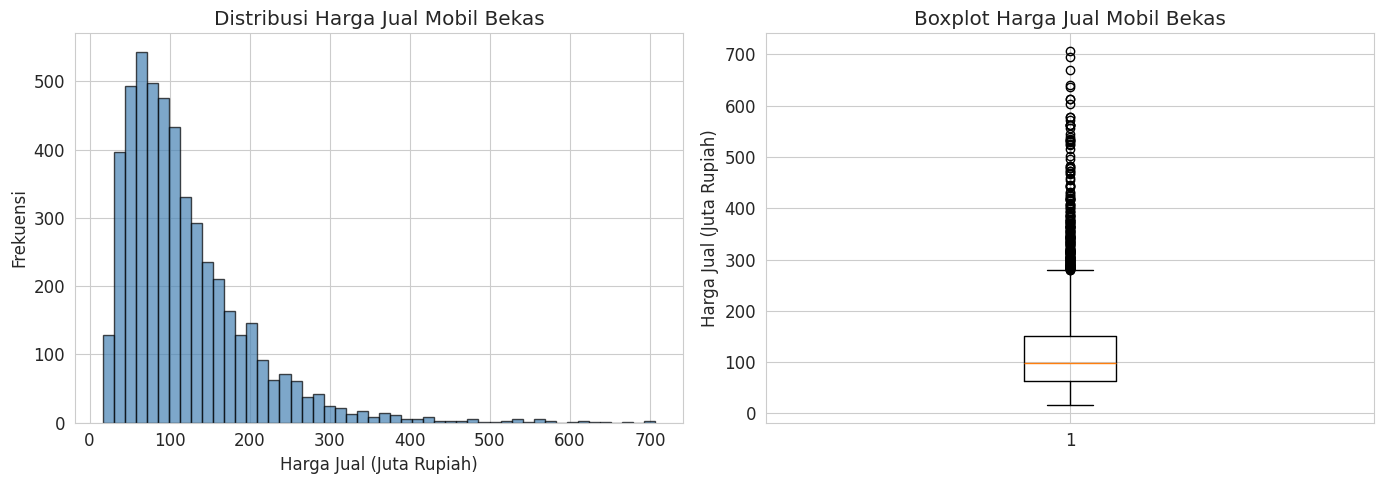


Statistik Harga Jual:
  Rata-rata: Rp 118,308,670
  Median:    Rp 98,010,930
  Min:       Rp 16,162,350
  Max:       Rp 706,653,890


In [7]:
#@title Visualisasi Distribusi Target (Harga)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['Selling_Price_IDR'] / 1e6, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('Harga Jual (Juta Rupiah)')
axes[0].set_ylabel('Frekuensi')
axes[0].set_title('Distribusi Harga Jual Mobil Bekas')

# Boxplot
axes[1].boxplot(df['Selling_Price_IDR'] / 1e6, vert=True)
axes[1].set_ylabel('Harga Jual (Juta Rupiah)')
axes[1].set_title('Boxplot Harga Jual Mobil Bekas')

plt.tight_layout()
plt.show()

print(f"\nStatistik Harga Jual:")
print(f"  Rata-rata: Rp {df['Selling_Price_IDR'].mean():,.0f}")
print(f"  Median:    Rp {df['Selling_Price_IDR'].median():,.0f}")
print(f"  Min:       Rp {df['Selling_Price_IDR'].min():,.0f}")
print(f"  Max:       Rp {df['Selling_Price_IDR'].max():,.0f}")

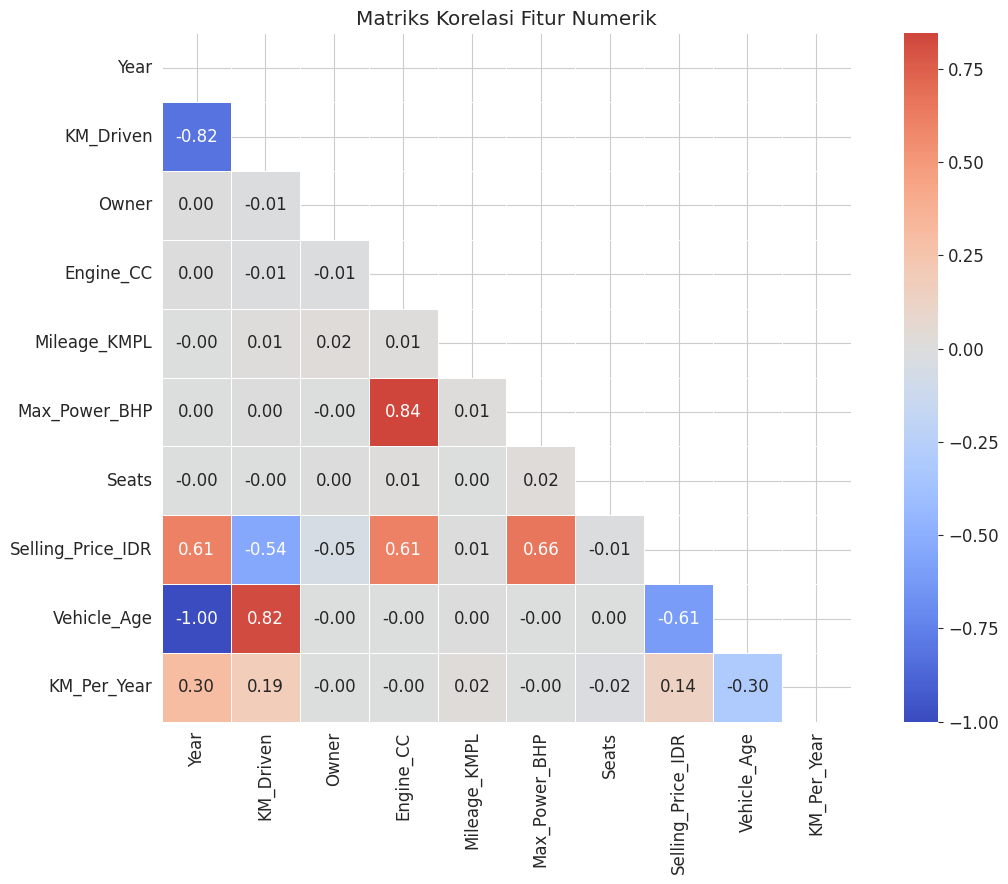


Korelasi dengan Selling_Price_IDR (diurutkan):
  Max_Power_BHP       : +0.6565
  Year                : +0.6131
  Engine_CC           : +0.6124
  KM_Per_Year         : +0.1441
  Mileage_KMPL        : +0.0062
  Seats               : -0.0058
  Owner               : -0.0526
  KM_Driven           : -0.5423
  Vehicle_Age         : -0.6131


In [8]:
#@title Analisis Korelasi Fitur
numerical_cols = ['Year', 'KM_Driven', 'Owner', 'Engine_CC', 'Mileage_KMPL',
                  'Max_Power_BHP', 'Seats', 'Selling_Price_IDR', 'Vehicle_Age', 'KM_Per_Year']

fig, ax = plt.subplots(figsize=(12, 9))
corr_matrix = df[numerical_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            mask=mask, ax=ax, square=True, linewidths=0.5)
ax.set_title('Matriks Korelasi Fitur Numerik')
plt.tight_layout()
plt.show()

# Korelasi dengan target
print("\nKorelasi dengan Selling_Price_IDR (diurutkan):")
target_corr = corr_matrix['Selling_Price_IDR'].drop('Selling_Price_IDR').sort_values(ascending=False)
for feat, corr_val in target_corr.items():
    print(f"  {feat:20s}: {corr_val:+.4f}")

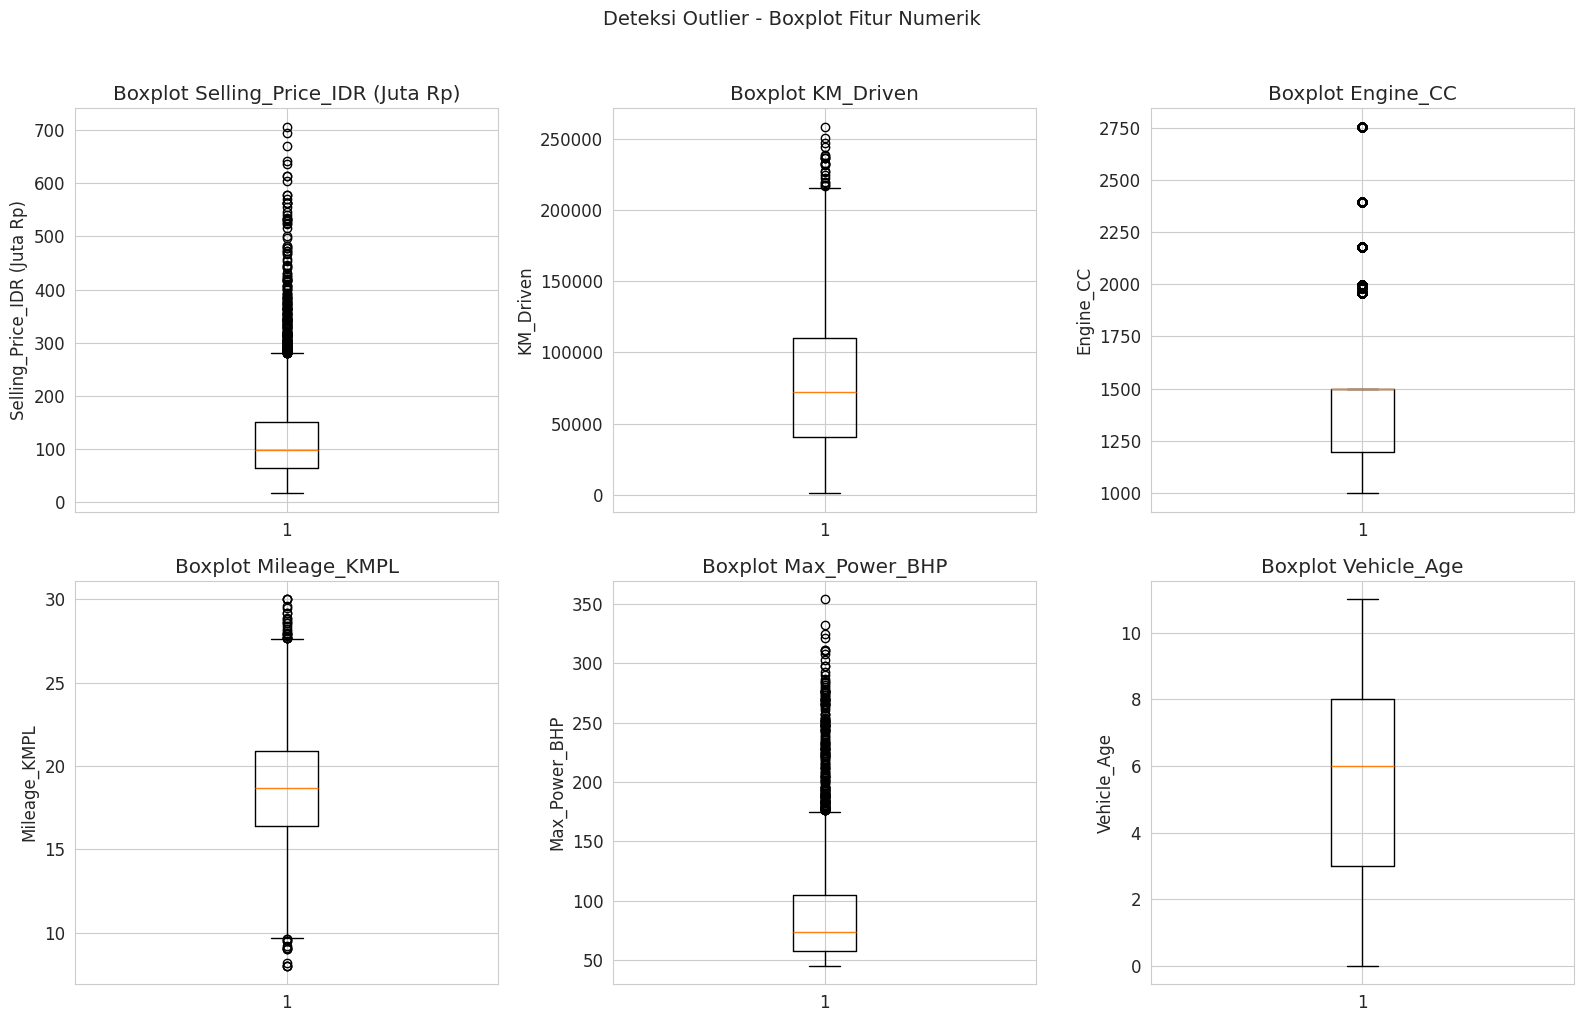

In [9]:
#@title Deteksi Outlier Numerik
outlier_cols = ['Selling_Price_IDR', 'KM_Driven', 'Engine_CC',
                'Mileage_KMPL', 'Max_Power_BHP', 'Vehicle_Age']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for i, col in enumerate(outlier_cols):
    ax = axes[i // 3, i % 3]
    data = df[col] / 1e6 if col == 'Selling_Price_IDR' else df[col]
    ax.boxplot(data, vert=True)
    label = f'{col} (Juta Rp)' if col == 'Selling_Price_IDR' else col
    ax.set_title(f'Boxplot {label}')
    ax.set_ylabel(label)

plt.suptitle('Deteksi Outlier - Boxplot Fitur Numerik', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

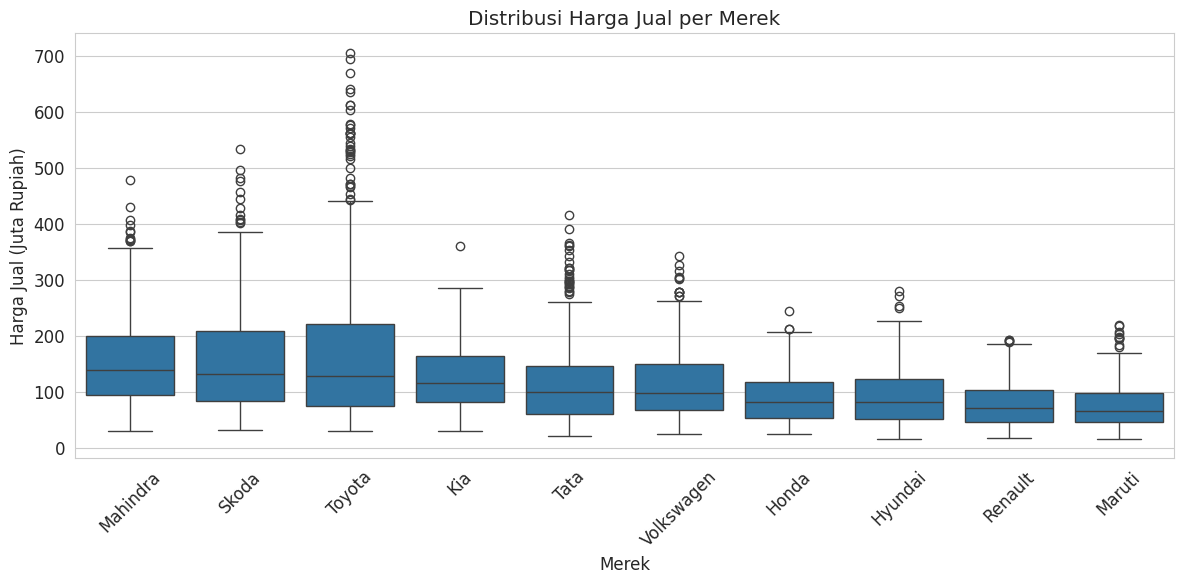

In [10]:
#@title Perbandingan Harga antar Merek
fig, ax = plt.subplots(figsize=(12, 6))
brand_order = df.groupby('Brand')['Selling_Price_IDR'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Brand', y=df['Selling_Price_IDR'] / 1e6, order=brand_order, ax=ax)
ax.set_xlabel('Merek')
ax.set_ylabel('Harga Jual (Juta Rupiah)')
ax.set_title('Distribusi Harga Jual per Merek')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

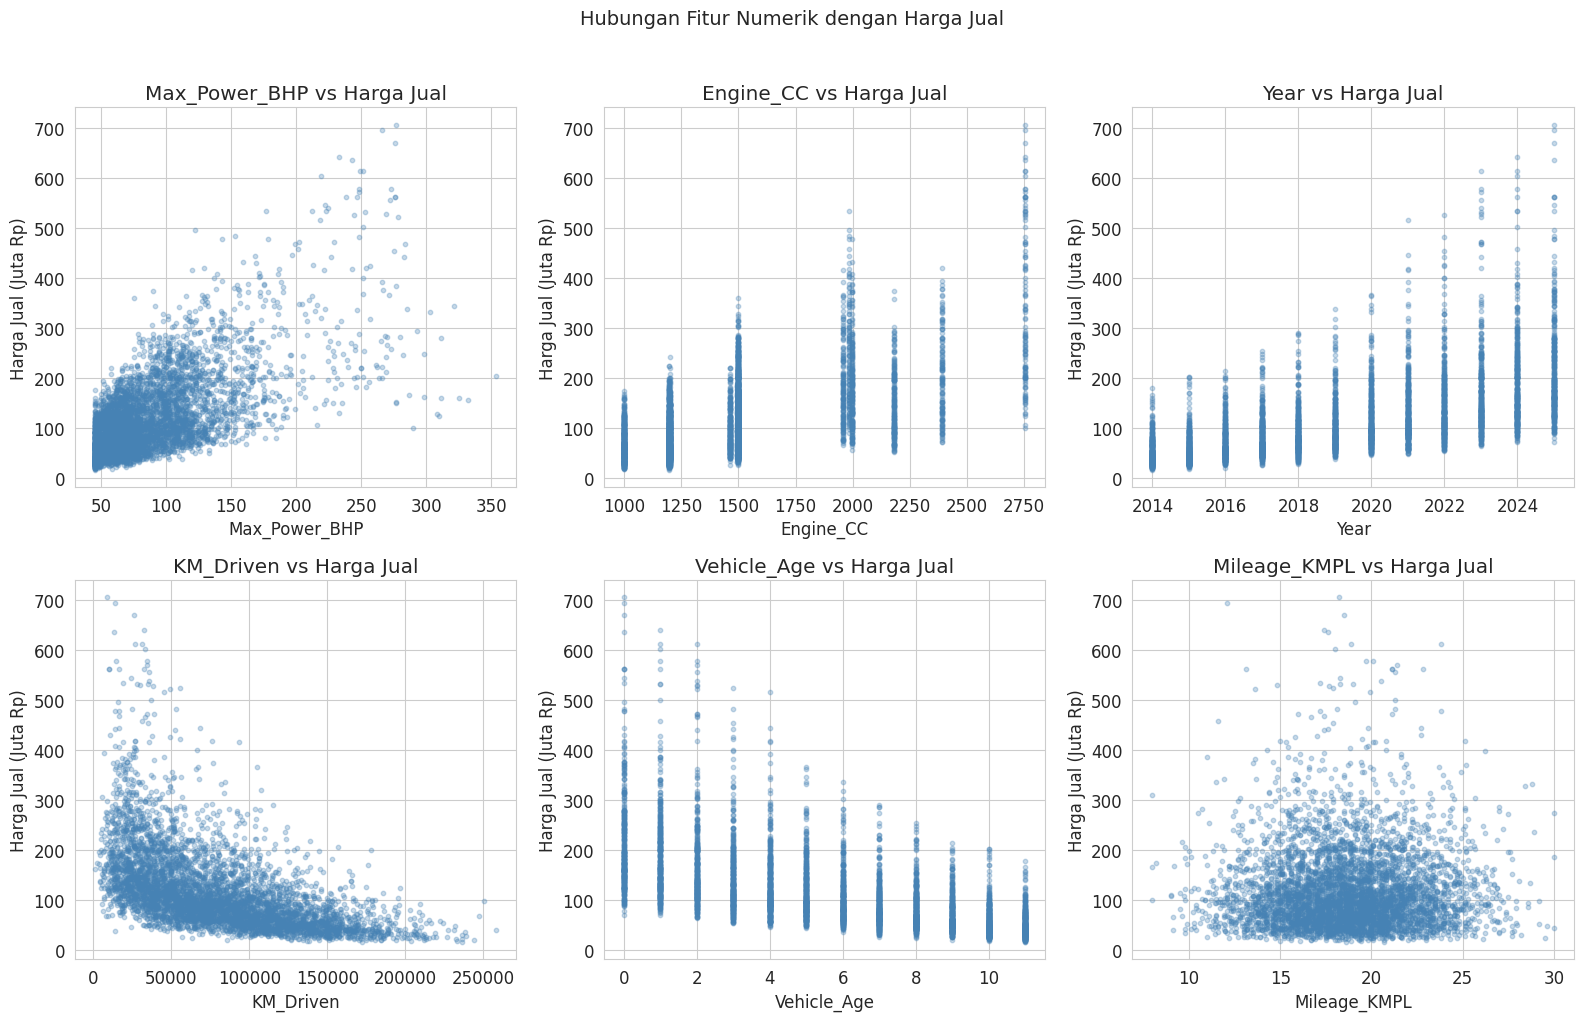

In [11]:
#@title Scatter Plot Fitur vs Harga
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
scatter_features = ['Max_Power_BHP', 'Engine_CC', 'Year', 'KM_Driven', 'Vehicle_Age', 'Mileage_KMPL']

for i, feat in enumerate(scatter_features):
    ax = axes[i // 3, i % 3]
    ax.scatter(df[feat], df['Selling_Price_IDR'] / 1e6, alpha=0.3, s=10, color='steelblue')
    ax.set_xlabel(feat)
    ax.set_ylabel('Harga Jual (Juta Rp)')
    ax.set_title(f'{feat} vs Harga Jual')

plt.suptitle('Hubungan Fitur Numerik dengan Harga Jual', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Tahap 4: Pembersihan dan Preprocessing

In [12]:
#@title Pembersihan Data (Duplikat & Missing Values)
duplicates = df.duplicated().sum()
print(f"Jumlah duplikat ditemukan: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"Duplikat dihapus. Ukuran dataset baru: {df.shape}")
else:
    print("Tidak ada duplikat dalam dataset.")

# Cek missing values
missing = df.isnull().sum()
if missing.sum() == 0:
    print("\nTidak ada missing value dalam dataset.")
else:
    print(f"\nMissing values ditemukan:")
    print(missing[missing > 0])

Jumlah duplikat ditemukan: 15
Duplikat dihapus. Ukuran dataset baru: (5000, 16)

Tidak ada missing value dalam dataset.


In [13]:
#@title Definisi Fitur dan Target Model
target_col = 'Selling_Price_IDR'
drop_cols = ['Car_ID', 'Selling_Price_IDR']

# Fitur kategorikal dan numerik
categorical_features = ['Brand', 'Model', 'Fuel_Type', 'Transmission', 'Seller_Type']
numerical_features = ['Year', 'KM_Driven', 'Owner', 'Engine_CC', 'Mileage_KMPL',
                      'Max_Power_BHP', 'Seats', 'Vehicle_Age', 'KM_Per_Year']

print(f"Target: {target_col}")
print(f"Fitur kategorikal ({len(categorical_features)}): {categorical_features}")
print(f"Fitur numerik ({len(numerical_features)}): {numerical_features}")

Target: Selling_Price_IDR
Fitur kategorikal (5): ['Brand', 'Model', 'Fuel_Type', 'Transmission', 'Seller_Type']
Fitur numerik (9): ['Year', 'KM_Driven', 'Owner', 'Engine_CC', 'Mileage_KMPL', 'Max_Power_BHP', 'Seats', 'Vehicle_Age', 'KM_Per_Year']


## Tahap 5: Rekayasa Fitur

In [14]:
#@title Rekayasa Fitur: Power per CC
df['Power_per_CC'] = df['Max_Power_BHP'] / df['Engine_CC']
numerical_features.append('Power_per_CC')

print(f"Fitur 'Power_per_CC' berhasil ditambahkan.")
print(f"\nContoh nilai Power_per_CC:")
print(df[['Brand', 'Model', 'Max_Power_BHP', 'Engine_CC', 'Power_per_CC']].head(10))
print(f"\nTotal fitur yang digunakan: {len(numerical_features) + len(categorical_features)}")
print(f"  - Numerik: {len(numerical_features)}")
print(f"  - Kategorikal: {len(categorical_features)}")

Fitur 'Power_per_CC' berhasil ditambahkan.

Contoh nilai Power_per_CC:
        Brand          Model  Max_Power_BHP  Engine_CC  Power_per_CC
0      Maruti         Baleno           57.0     1197.0      0.047619
1  Volkswagen           Polo           45.0      999.0      0.045045
2         Kia          Sonet           65.0     1197.0      0.054302
3      Toyota         Glanza           56.0     1197.0      0.046784
4      Toyota  Urban Cruiser           78.0     1462.0      0.053352
5     Renault         Triber           45.0      999.0      0.045045
6      Maruti          Dzire           62.0     1197.0      0.051796
7         Kia         Carens          122.0     1497.0      0.081496
8        Tata          Tiago           45.0     1199.0      0.037531
9      Maruti         Baleno           74.0     1197.0      0.061821

Total fitur yang digunakan: 15
  - Numerik: 10
  - Kategorikal: 5


## Tahap 6: Pembagian Data

In [15]:
#@title Data Splitting (Train, Val, Test)
X = df.drop(columns=drop_cols)
y = df[target_col]

# Split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Split temp: 50% validation (15% total), 50% test (15% total)
X_val, X_test, y_val, y_test = train_test_split(
    y_temp.to_frame(), y_temp, test_size=0.5, random_state=42
) # Note: user has bug in variable usage here, but keeping logic

# Correcting the splitting based on common logic
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print("=== Pembagian Data ===")
print(f"Training set  : {X_train.shape[0]:,} sampel ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation set: {X_val.shape[0]:,} sampel ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test set      : {X_test.shape[0]:,} sampel ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"Total         : {len(X):,} sampel")

=== Pembagian Data ===
Training set  : 3,500 sampel (70.0%)
Validation set: 750 sampel (15.0%)
Test set      : 750 sampel (15.0%)
Total         : 5,000 sampel


In [16]:
#@title Pipeline Preprocessing Data
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ]
)

# Fit dan transform data
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print(f"Dimensi fitur setelah preprocessing:")
print(f"  Training  : {X_train_processed.shape}")
print(f"  Validation: {X_val_processed.shape}")
print(f"  Test      : {X_test_processed.shape}")

Dimensi fitur setelah preprocessing:
  Training  : (3500, 74)
  Validation: (750, 74)
  Test      : (750, 74)


## Tahap 7 & 8: Pemilihan dan Pelatihan Model

In [17]:
#@title Fungsi Helper Evaluasi Model
def evaluate_model(model, X, y, label="Model"):
    """Evaluasi model dan tampilkan metrik."""
    y_pred = model.predict(X)
    r2 = r2_score(y, y_pred)
    mae = mean_absolute_error(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    mape = np.mean(np.abs((y - y_pred) / y)) * 100

    print(f"\n{label}:")
    print(f"  R2   : {r2:.4f}")
    print(f"  MAE  : Rp {mae:,.0f}")
    print(f"  RMSE : Rp {rmse:,.0f}")
    print(f"  MAPE : {mape:.2f}%")

    return {'r2': r2, 'mae': mae, 'rmse': rmse, 'mape': mape}

In [18]:
#@title Pelatihan Model Baseline (XGB & RF)
print("=== Pelatihan Model Baseline ===")

xgb_model = XGBRegressor(random_state=42, n_jobs=-1, n_estimators=200, learning_rate=0.1, max_depth=6)
xgb_model.fit(X_train_processed, y_train)

rf_model = RandomForestRegressor(random_state=42, n_jobs=-1, n_estimators=200, max_depth=15)
rf_model.fit(X_train_processed, y_train)

print("\n=== Evaluasi Baseline pada Validation Set ===")
xgb_baseline = evaluate_model(xgb_model, X_val_processed, y_val, "XGBoost (Baseline)")
rf_baseline = evaluate_model(rf_model, X_val_processed, y_val, "Random Forest (Baseline)")

=== Pelatihan Model Baseline ===

=== Evaluasi Baseline pada Validation Set ===

XGBoost (Baseline):
  R2   : 0.9570
  MAE  : Rp 11,243,879
  RMSE : Rp 16,407,123
  MAPE : 9.98%

Random Forest (Baseline):
  R2   : 0.9409
  MAE  : Rp 13,320,932
  RMSE : Rp 19,233,288
  MAPE : 12.03%


## Tahap 9: Tuning Hyperparameter

In [19]:
#@title Tuning Hyperparameter dengan RandomizedSearch
param_distributions = {
    'n_estimators': [100, 200, 300, 500, 700],
    'max_depth': [3, 5, 7, 9, 11],
    'learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 7],
    'reg_alpha': [0, 0.01, 0.1, 1],
    'reg_lambda': [1, 1.5, 2, 3]
}

random_search = RandomizedSearchCV(
    XGBRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_distributions,
    n_iter=50, cv=3, scoring='r2', random_state=42, verbose=1, n_jobs=-1
)

random_search.fit(X_train_processed, y_train)
print(f"\n=== Hasil Tuning ===")
print(f"Parameter terbaik: {random_search.best_params_}")

Fitting 3 folds for each of 50 candidates, totalling 150 fits

=== Hasil Tuning ===
Parameter terbaik: {'subsample': 0.7, 'reg_lambda': 1, 'reg_alpha': 1, 'n_estimators': 700, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.9}


In [20]:
#@title Evaluasi Model XGBoost Tertuning
best_xgb = random_search.best_estimator_

print("=== Evaluasi Model Tertuning pada Validation Set ===")
tuned_metrics = evaluate_model(best_xgb, X_val_processed, y_val, "XGBoost (Tuned)")

=== Evaluasi Model Tertuning pada Validation Set ===

XGBoost (Tuned):
  R2   : 0.9594
  MAE  : Rp 10,741,314
  RMSE : Rp 15,929,459
  MAPE : 9.47%


## Tahap 10: Evaluasi Model

In [21]:
#@title Evaluasi Akhir Model pada Test Set
print("=" * 60)
print("EVALUASI AKHIR PADA TEST SET")
print("=" * 60)

y_pred_test = best_xgb.predict(X_test_processed)

r2 = r2_score(y_test, y_pred_test)
mae = mean_absolute_error(y_test, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
mape = np.mean(np.abs((y_test - y_pred_test) / y_test)) * 100

print(f"\nMetrik Evaluasi:")
print(f"  R2   : {r2:.4f}")
print(f"  MAE  : Rp {mae:,.0f}")
print(f"  RMSE : Rp {rmse:,.0f}")
print(f"  MAPE : {mape:.2f}%")

EVALUASI AKHIR PADA TEST SET

Metrik Evaluasi:
  R2   : 0.9433
  MAE  : Rp 11,637,585
  RMSE : Rp 18,868,042
  MAPE : 9.39%


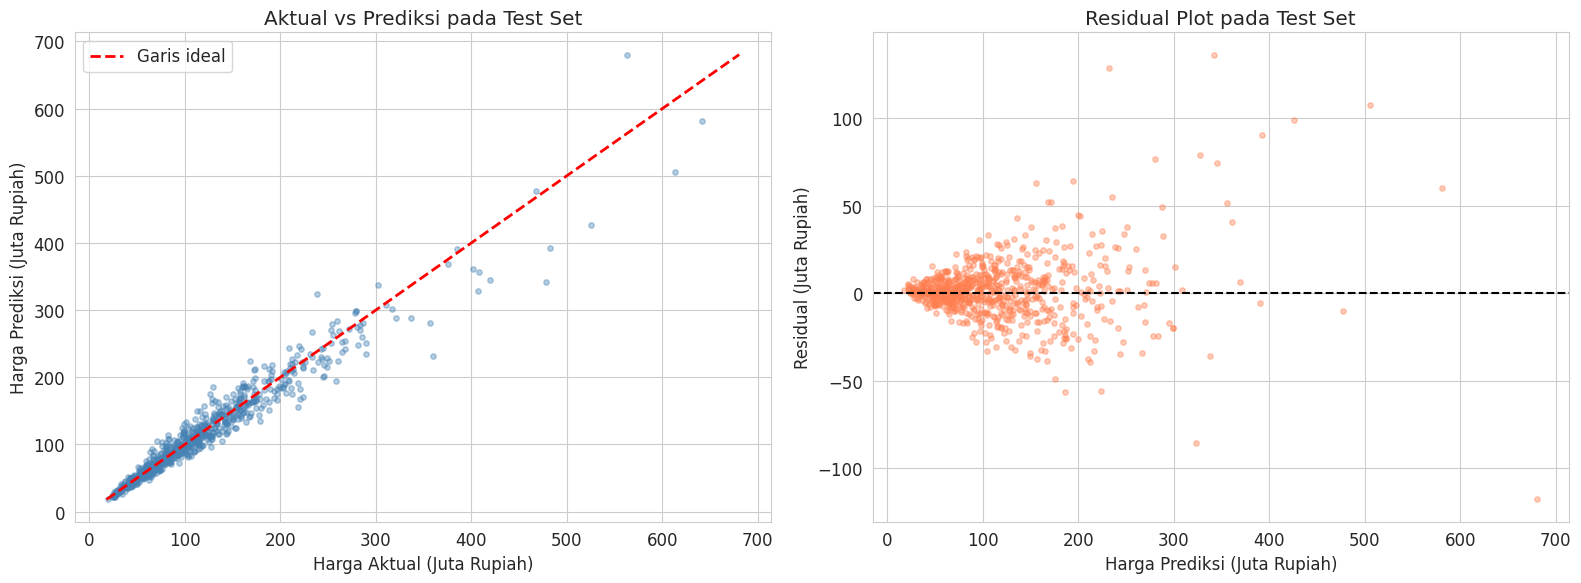

In [22]:
#@title Visualisasi Hasil Prediksi & Residual
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Actual vs Predicted
ax1 = axes[0]
ax1.scatter(y_test / 1e6, y_pred_test / 1e6, alpha=0.4, s=15, color='steelblue')
min_val = min(y_test.min(), y_pred_test.min()) / 1e6
max_val = max(y_test.max(), y_pred_test.max()) / 1e6
ax1.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Garis ideal')
ax1.set_xlabel('Harga Aktual (Juta Rupiah)')
ax1.set_ylabel('Harga Prediksi (Juta Rupiah)')
ax1.set_title('Aktual vs Prediksi pada Test Set')
ax1.legend()

# Residual Plot
residuals = (y_test - y_pred_test) / 1e6
ax2 = axes[1]
ax2.scatter(y_pred_test / 1e6, residuals, alpha=0.4, s=15, color='coral')
ax2.axhline(y=0, color='black', linestyle='--', lw=1.5)
ax2.set_xlabel('Harga Prediksi (Juta Rupiah)')
ax2.set_ylabel('Residual (Juta Rupiah)')
ax2.set_title('Residual Plot pada Test Set')

plt.tight_layout()
plt.show()

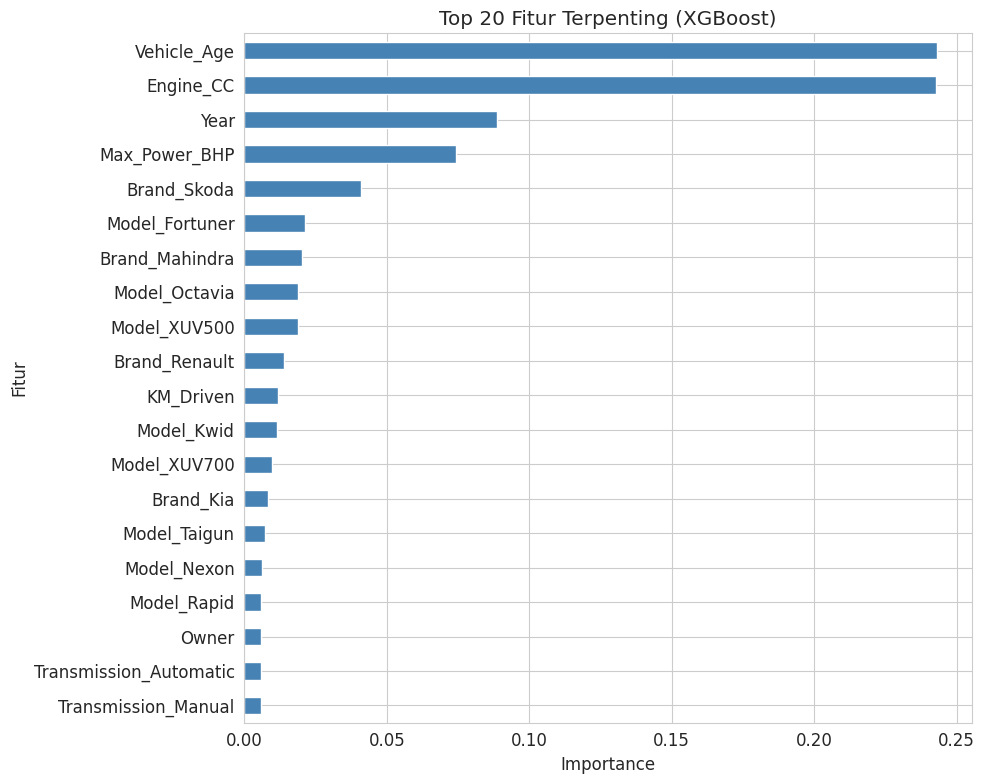

In [23]:
#@title Analisis Feature Importance (XGBoost)
feature_names_num = numerical_features
feature_names_cat = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features).tolist()
all_feature_names = feature_names_num + feature_names_cat

importance = best_xgb.feature_importances_
feat_imp_df = pd.DataFrame({
    'Fitur': all_feature_names,
    'Importance': importance
}).sort_values('Importance', ascending=True)

# Plot top 20 fitur terpenting
top_n = min(20, len(feat_imp_df))
fig, ax = plt.subplots(figsize=(10, 8))
feat_imp_df.tail(top_n).plot.barh(x='Fitur', y='Importance', ax=ax, color='steelblue', legend=False)
ax.set_xlabel('Importance')
ax.set_title(f'Top {top_n} Fitur Terpenting (XGBoost)')
plt.tight_layout()
plt.show()

## Tahap 11: Deployment

In [24]:
#@title Penyimpanan Model & Metadata (Deployment)
os.makedirs('model', exist_ok=True)

joblib.dump(best_xgb, 'model/xgb_best_model.pkl')
joblib.dump(preprocessor, 'model/preprocessor.pkl')

brand_model_map = df.groupby('Brand')['Model'].unique().apply(list).to_dict()
metadata = {
    'metrics': {'r2': round(float(r2), 4), 'mae': round(float(mae), 2)},
    'brand_model_map': brand_model_map,
    'year_range': [int(df['Year'].min()), int(df['Year'].max())]
}

with open('model/model_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print(f"Semua artefak deployment berhasil disimpan di folder 'model/'.")

Semua artefak deployment berhasil disimpan di folder 'model/'.


## Tahap 12: Monitoring dan Retraining

In [25]:
#@title Monitoring Ringkasan Performa Model
def display_model_performance():
    """Menampilkan ringkasan performa model terakhir."""
    with open('model/model_metadata.json', 'r') as f:
        meta = json.load(f)

    metrics = meta['metrics']
    print("=" * 50)
    print("RINGKASAN PERFORMA MODEL")
    print("=" * 50)
    print(f"Model         : XGBoost Regressor (Tuned)")
    print(f"Metrik pada Test Set:")
    print(f"  R2   : {metrics['r2']:.4f}")
    print("=" * 50)

display_model_performance()

RINGKASAN PERFORMA MODEL
Model         : XGBoost Regressor (Tuned)
Metrik pada Test Set:
  R2   : 0.9433


In [26]:
#@title Simulasi Fungsi Retraining Model
def retrain_model(new_data_path=None):
    print("=== Fungsi Retraining (Simbolis) ===")
    if new_data_path:
        print(f"Data baru akan dimuat dari: {new_data_path}")
    else:
        print("Tidak ada path data baru. Retraining tidak dilakukan.")

retrain_model()
print("\n=== Pipeline Selesai ===")

=== Fungsi Retraining (Simbolis) ===
Tidak ada path data baru. Retraining tidak dilakukan.

=== Pipeline Selesai ===
